# Bronze Layer — Raw Data Landing
---
**Objective:** To read and save raw data exactly as is, without any modification.

**Input:** `US_Accidents_March23.csv`

**Output:** `Bronze_Layer/US_Accidents_Bronze.csv`

## 1. Imports & Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

os.makedirs('Bronze_Layer', exist_ok=True)
print('Libraries imported | Bronze_Layer folder ready')

Libraries imported | Bronze_Layer folder ready


## 2. Load Raw Data

In [2]:
df_bronze = pd.read_csv('US_Accidents_March23.csv', low_memory=False)
print(f'Shape: {df_bronze.shape[0]:,} rows | {df_bronze.shape[1]} columns')
df_bronze.head(3)

Shape: 500,000 rows | 46 columns


,ID,Source,Severity,Start_Time,End_Time,Start_Lat,Start_Lng,End_Lat,End_Lng,Distance(mi),...,Roundabout,Station,Stop,Traffic_Calming,Traffic_Signal,Turning_Loop,Sunrise_Sunset,Civil_Twilight,Nautical_Twilight,Astronomical_Twilight
0,A-2047758,Source2,2,2019-06-12 10:10:56,2019-06-12 10:55:58,30.641211,-91.153481,NaN,NaN,0.000,...,False,False,False,False,True,False,Day,Day,Day,Day
1,A-4694324,Source1,2,2022-12-03 23:37:14.000000000,2022-12-04 01:56:53.000000000,38.990562,-77.399070,38.990037,-77.398282,0.056,...,False,False,False,False,False,False,Night,Night,Night,Night
2,A-5006183,Source1,2,2022-08-20 13:13:00.000000000,2022-08-20 15:22:45.000000000,34.661189,-120.492822,34.661189,-120.492442,0.022,...,False,False,False,False,True,False,Day,Day,Day,Day


## 3. Column Overview

In [3]:
print('=== Columns ===')
print(df_bronze.columns.tolist())

=== Columns ===
['ID', 'Source', 'Severity', 'Start_Time', 'End_Time', 'Start_Lat', 'Start_Lng', 'End_Lat', 'End_Lng', 'Distance(mi)', 'Description', 'Street', 'City', 'County', 'State', 'Zipcode', 'Country', 'Timezone', 'Airport_Code', 'Weather_Timestamp', 'Temperature(F)', 'Wind_Chill(F)', 'Humidity(%)', 'Pressure(in)', 'Visibility(mi)', 'Wind_Direction', 'Wind_Speed(mph)', 'Precipitation(in)', 'Weather_Condition', 'Amenity', 'Bump', 'Crossing', 'Give_Way', 'Junction', 'No_Exit', 'Railway', 'Roundabout', 'Station', 'Stop', 'Traffic_Calming', 'Traffic_Signal', 'Turning_Loop', 'Sunrise_Sunset', 'Civil_Twilight', 'Nautical_Twilight', 'Astronomical_Twilight']


In [4]:
print('=== Data Types ===')
print(df_bronze.dtypes.to_string())

=== Data Types ===
ID                           str
Source                       str
Severity                   int64
Start_Time                   str
End_Time                     str
Start_Lat                float64
Start_Lng                float64
End_Lat                  float64
End_Lng                  float64
Distance(mi)             float64
Description                  str
Street                       str
City                         str
County                       str
State                        str
Zipcode                      str
Country                      str
Timezone                     str
Airport_Code                 str
Weather_Timestamp            str
Temperature(F)           float64
Wind_Chill(F)            float64
Humidity(%)              float64
Pressure(in)             float64
Visibility(mi)           float64
Wind_Direction               str
Wind_Speed(mph)          float64
Precipitation(in)        float64
Weather_Condition            str
Amenity                 

In [5]:
print('=== Basic Statistics ===')
df_bronze.describe()

=== Basic Statistics ===


,Severity,Start_Lat,Start_Lng,End_Lat,End_Lng,Distance(mi),Temperature(F),Wind_Chill(F),Humidity(%),Pressure(in),Visibility(mi),Wind_Speed(mph),Precipitation(in)
count,500000.000000,500000.000000,500000.000000,279623.000000,279623.000000,500000.000000,489534.000000,370983.000000,488870.000000,491072.000000,488709.000000,463013.000000,357384.000000
mean,2.212748,36.206421,-94.736583,36.273192,-95.776553,0.564317,61.646254,58.229028,64.834921,29.536621,9.091540,7.681347,0.008289
std,0.486661,5.071411,17.405761,5.265333,18.120211,1.774872,19.000133,22.352246,22.826158,1.008666,2.708083,5.431361,0.101865
min,1.000000,24.562117,-124.497420,24.570110,-124.497419,0.000000,-77.800000,-53.200000,1.000000,0.120000,0.000000,0.000000,0.000000
25%,2.000000,33.416823,-117.233047,33.474773,-117.778324,0.000000,49.000000,43.000000,48.000000,29.370000,10.000000,4.600000,0.000000
50%,2.000000,35.832147,-87.794365,36.192669,-88.039013,0.029000,64.000000,62.000000,67.000000,29.860000,10.000000,7.000000,0.000000
75%,2.000000,40.082443,-80.359601,40.181341,-80.252449,0.465000,76.000000,75.000000,84.000000,30.030000,10.000000,10.400000,0.000000
max,4.000000,48.999569,-67.484130,48.998901,-67.484130,193.479996,207.000000,207.000000,100.000000,38.440000,130.000000,822.800000,10.130000


## 4. Missing Values Analysis

In [6]:
missing = (df_bronze.isnull().sum() / len(df_bronze) * 100).round(2)
missing = missing[missing > 0].sort_values(ascending=False)
print(f'Columns with missing values: {len(missing)}')
print(missing.to_string())

Columns with missing values: 20
End_Lat                  44.08
End_Lng                  44.08
Precipitation(in)        28.52
Wind_Chill(F)            25.80
Wind_Speed(mph)           7.40
Visibility(mi)            2.26
Wind_Direction            2.24
Humidity(%)               2.23
Weather_Condition         2.22
Temperature(F)            2.09
Pressure(in)              1.79
Weather_Timestamp         1.53
Nautical_Twilight         0.30
Astronomical_Twilight     0.30
Sunrise_Sunset            0.30
Civil_Twilight            0.30
Airport_Code              0.29
Street                    0.14
Timezone                  0.10
Zipcode                   0.02


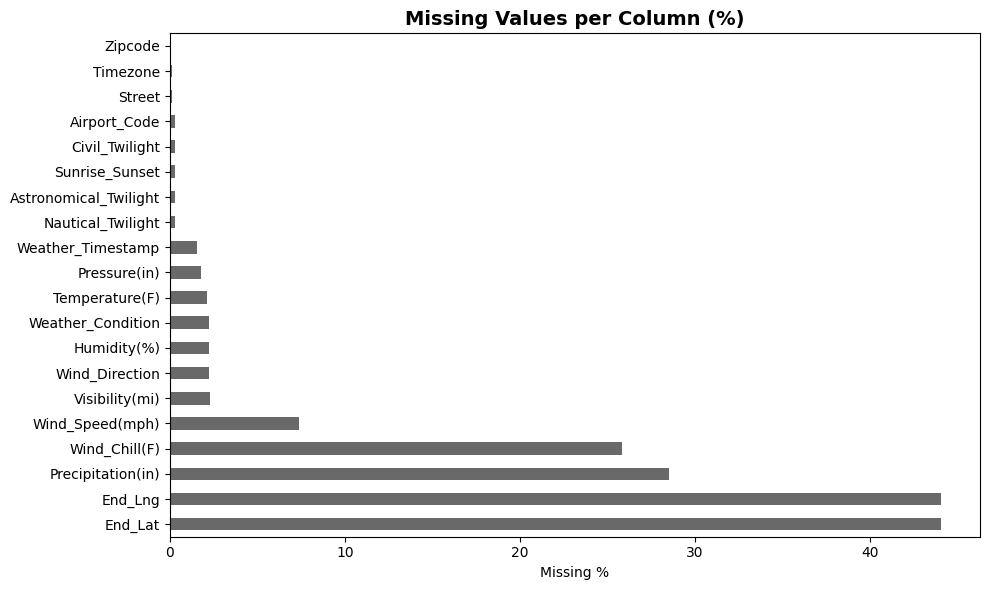

In [7]:
fig, ax = plt.subplots(figsize=(10, 6))
missing.plot(kind='barh', color='#696969', ax=ax)
ax.set_title('Missing Values per Column (%)', fontsize=14, fontweight='bold')
ax.set_xlabel('Missing %')
plt.tight_layout(); plt.show(); plt.close()

## 5. Save Bronze Layer

In [8]:
df_bronze.to_csv('Bronze_Layer/US_Accidents_Bronze.csv', index=False)
print(f'Saved: Bronze_Layer/US_Accidents_Bronze.csv')
print(f'Rows: {df_bronze.shape[0]:,} | Columns: {df_bronze.shape[1]}')

Saved: Bronze_Layer/US_Accidents_Bronze.csv
Rows: 500,000 | Columns: 46
